# Análisis de los datos

## Librerias

In [3]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

## Importación de los datos limpios

In [4]:
path = 'datos/datos_clean.csv'
df = pd.read_csv(path)

df['texto'] = df['texto'].astype(str)
df['texto_clean'] = df['texto_clean'].astype(str)

## Calculo de los embedings

In [5]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

docs = df['texto'].astype(str).tolist()

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

## Análisis de polaridad

In [6]:
# Descargamos las stopwords
nltk.download('stopwords')
stop_words_es = stopwords.words('spanish')

# Función para calcular la polaridad (de -1.0 a 1.0)
def calcular_polaridad(texto):
    # Nota: TextBlob funciona nativamente en inglés. 
    # Usamos una traducción interna rápida al inglés para evaluar textos en español.
    try:
        analisis = TextBlob(texto).translate(from_lang='es', to='en')
        return analisis.sentiment.polarity
    except:
        # En caso de error de conexión con el traductor, usamos el original
        return TextBlob(texto).sentiment.polarity

# Aplicamos la función y creamos una nueva columna
df['polaridad'] = df['texto_clean'].apply(calcular_polaridad)

# Etiquetamos el resultado para hacerlo más legible
df['sentimiento'] = df['polaridad'].apply(
    lambda p: 'Positivo' if p > 0.1 else ('Negativo' if p < -0.1 else 'Neutral')
)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joanm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Topic modeling

In [7]:
stopwords_es = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se',
    'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al',
    'lo', 'es', 'si', 'ha', 'más', 'pero', 'sus', 'le', 'ya',
    'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando',
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay',
    'donde', 'quien', 'desde', 'todo', 'nos', 'durante',
    'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese',
    'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes',
    'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra',
    'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada',
    'muchos', 'cual', 'poco', 'ella', 'estar', 'estas',
    'algunas', 'algo', 'nosotros', 'como', 'ser', 'son', 'está', 
    'han', 'sino', 'solo'
]

mis_stopwords = list(set(stopwords_es))

In [15]:
#  Reduce dimensionality
umap_model = UMAP(
    n_neighbors=7,
    n_components=5,
    min_dist=0.0,      
    metric="cosine",  
    random_state=42
)

# Cluster reduced embeddings
hdbscan_model = HDBSCAN(
    min_cluster_size=200,
    min_samples=7,
    cluster_selection_method="eom",
    prediction_data=True
)

# Tokenize topics
vectorizer_model = CountVectorizer(
    stop_words=mis_stopwords,
    min_df=2,
    ngram_range=(1, 2)
)

# Create topic representation
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="multilingual",
    verbose=True
)

topics, probs = topic_model.fit_transform(
    docs,
    embeddings
)

df['id_tema'] = topics

display(df[['texto', 'periodico', 'id_tema']])

2026-05-21 21:56:42,821 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 21:56:58,267 - BERTopic - Dimensionality - Completed ✓
2026-05-21 21:56:58,269 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 21:56:58,666 - BERTopic - Cluster - Completed ✓
2026-05-21 21:56:58,670 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 21:57:16,067 - BERTopic - Representation - Completed ✓


,texto,periodico,id_tema
0,En la competición de visualizaciones del vídeo...,eldiario.es,0
1,Hay asuntos que una no abandona al salir del j...,eldiario.es,0
2,En la competición de visualizaciones del vídeo...,eldiario.es,0
3,Como un gélido bisturí explorador de las mise...,eldiario.es,0
4,Un minuto y diez segundos. Eso es lo que dura ...,eldiario.es,0
...,...,...,...
9995,"abascal y sánchez, en una sesión de control. e...",el español,0
9996,los argumentos del actual portavoz paradisputa...,el español,0
9997,"pedro sánchez y oriol junqueras, este jueves e...",el español,0
9998,quiso el destino que el último día de campaña ...,el español,0


In [16]:
unique_topics = sorted(set(topics))

for topic_id in unique_topics:
    if topic_id == -1:
        continue

    print("\n" + "=" * 80)
    print(f"TOPIC {topic_id}")

    words = topic_model.get_topic(topic_id)
    topic_words = [word for word, score in words[:10]]

    print(topic_words)


TOPIC 0
['sánchez', 'gobierno', 'años', 'españa', 'política', 'dos', 'vez', 'era', 'puede', 'pp']

TOPIC 1
['españa', 'personas', 'años', 'gobierno', 'vivienda', 'millones', 'social', 'puede', 'animales', 'cada']

TOPIC 2
['trump', 'estados', 'unidos', 'estados unidos', 'guerra', 'venezuela', 'china', 'mundo', 'rusia', 'eeuu']

TOPIC 3
['israel', 'gaza', 'palestina', 'genocidio', 'palestino', 'israelí', 'pueblo', 'palestinos', 'estado', 'internacional']

TOPIC 4
['irán', 'israel', 'guerra', 'trump', 'estados', 'unidos', 'estados unidos', 'iraní', 'nuclear', 'régimen']

TOPIC 5
['fascismo', 'mundo', 'capitalismo', 'mundial', 'países', 'social', 'fue', 'china', 'poder', 'global']


In [17]:
#print de los coherence scores de los topics
tokenized_docs = [doc.lower().split() for doc in docs]

# Diccionario de Gensim:
# palabra -> ID único
dictionary = Dictionary(tokenized_docs)

print("=" * 80)
print("COHERENCE SCORE POR TOPIC")
print("=" * 80)

for topic_id in unique_topics:

    # Ignorar outliers de BERTopic
    if topic_id == -1:
        continue

    # Obtener palabras representativas del topic
    words = topic_model.get_topic(topic_id)

    # Seleccionar las 10 palabras más importantes
    topic_words = [word for word, score in words[:10]]

    # Obtenemos el coherence score
    coherence_model = CoherenceModel(
        topics=[topic_words],
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )

    # Calcular coherence del topic individual
    coherence = coherence_model.get_coherence()

    print(f"Topic {topic_id}: {coherence:.4f}")

COHERENCE SCORE POR TOPIC
Topic 0: 0.3908
Topic 1: 0.3584
Topic 2: 0.7237
Topic 3: 0.8136
Topic 4: 0.7554
Topic 5: 0.4888


In [18]:
df.head(5)

,periodico,titulo,texto,url,texto_clean,polaridad,sentimiento,id_tema
0,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...,competición visualización vídeo impactante ara...,0.061538,Neutral,0
1,eldiario.es,Juicio a Vivotecnia: cómo demostrar un exceso...,Hay asuntos que una no abandona al salir del j...,https://www.eldiario.es/caballodenietzsche/jui...,asunto no abandonar salir juzgado caso quedar ...,0.071429,Neutral,0
2,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...,competición visualización vídeo impactante ara...,0.061538,Neutral,0
3,eldiario.es,Mentiras y cintas de vídeo,Como un gélido bisturí explorador de las mise...,https://www.eldiario.es/aragon/el-prismatico/m...,gélido bisturí explorador miseria humano defin...,0.212500,Positivo,0
4,eldiario.es,Vosotros sois la televisión,Un minuto y diez segundos. Eso es lo que dura ...,https://www.eldiario.es/aragon/el-prismatico/t...,minuto segundo durar vídeo informativo televis...,0.000000,Neutral,0


## Temas en función del periodico

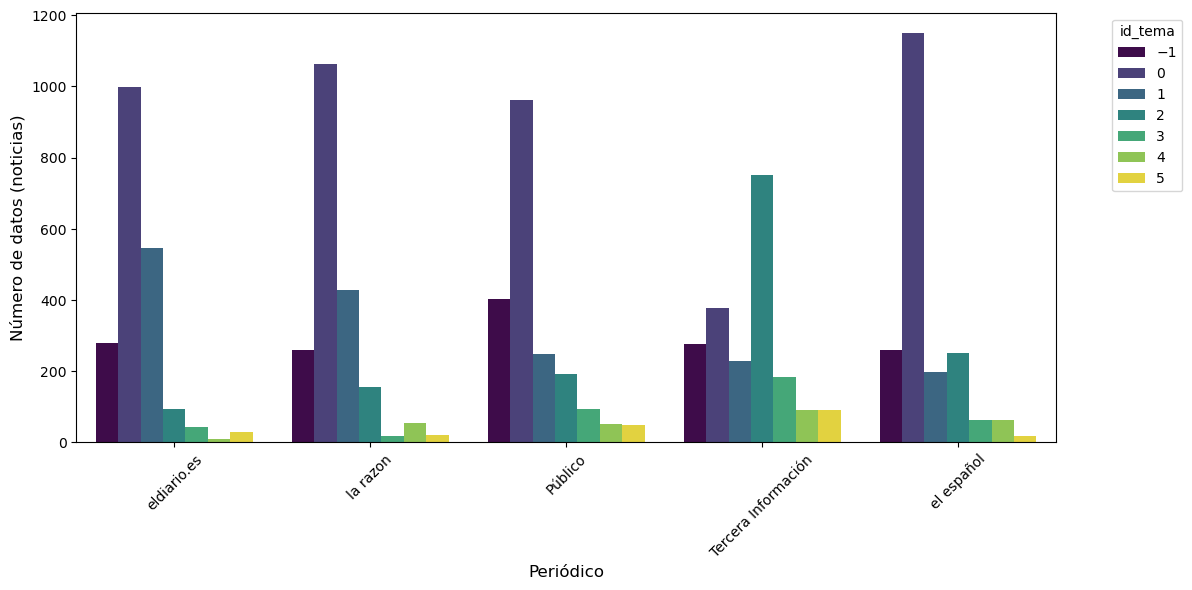

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='periodico', hue='id_tema', palette='viridis')
plt.xlabel('Periódico', fontsize=12)
plt.ylabel('Número de datos (noticias)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='id_tema', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Polaridad en función del periodico y del tema

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es        83        31      164
1             la razon        79        42      140
2              Público        83        54      265
3  Tercera Información        57        72      147
4           el español        72        41      147


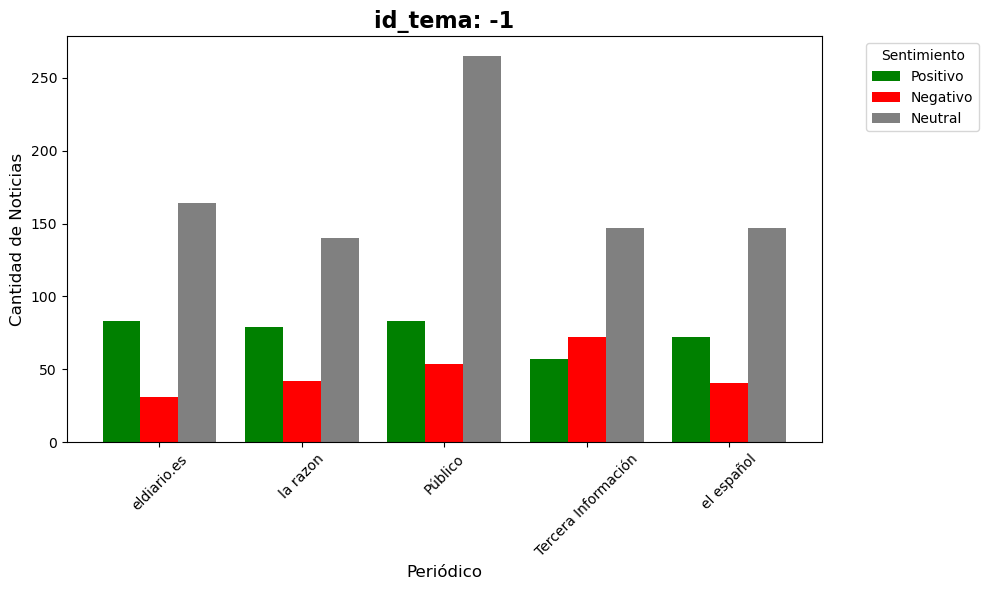

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es       309       123      566
1             la razon       376       110      578
2              Público       348       129      485
3  Tercera Información        96        71      211
4           el español       346       177      627


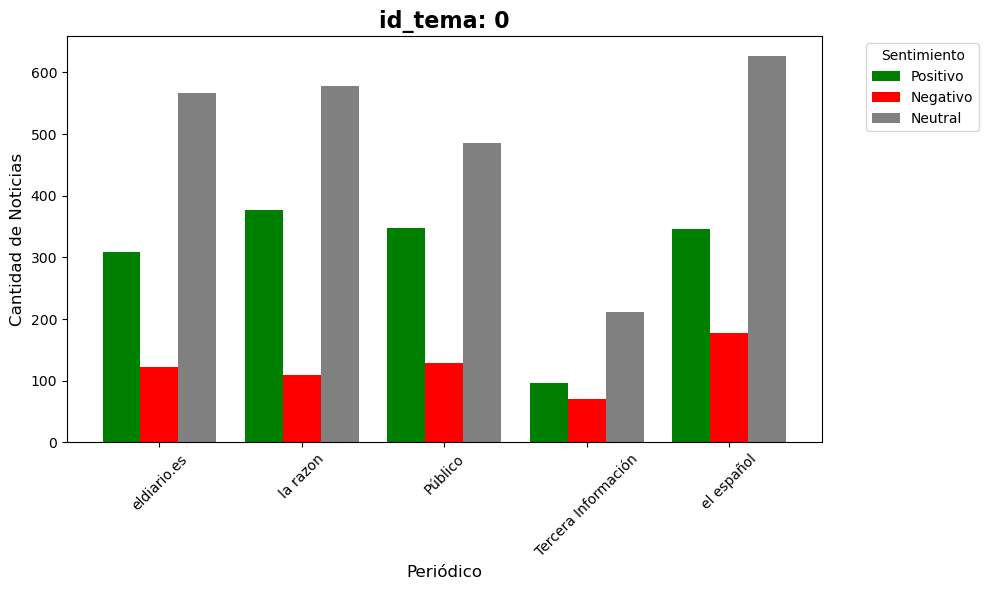

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es       129        70      347
1             la razon       109        47      271
2              Público        52        32      164
3  Tercera Información        53        33      142
4           el español        53        23      121


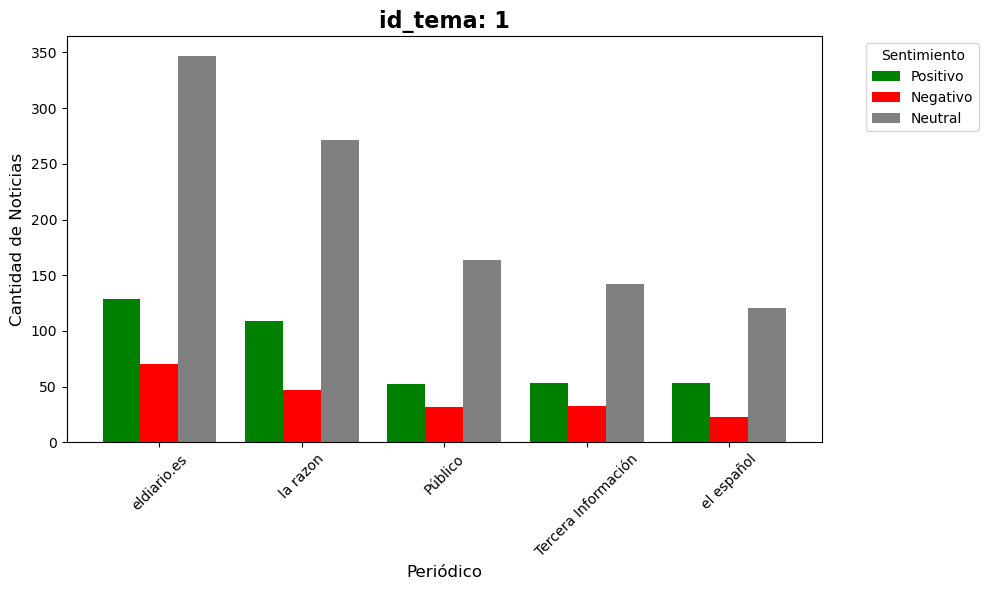

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es        23        21       51
1             la razon        34        26       95
2              Público        38        45      109
3  Tercera Información       117       228      405
4           el español        44        56      150


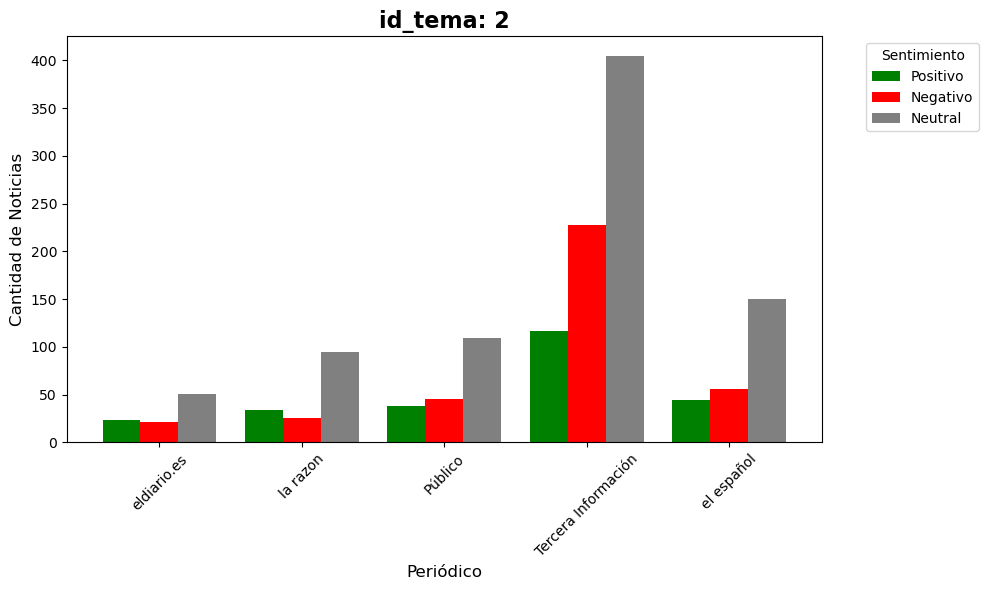

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es         7         7       30
1             la razon         4         3       10
2              Público        19        20       56
3  Tercera Información        34        68       83
4           el español         6        17       39


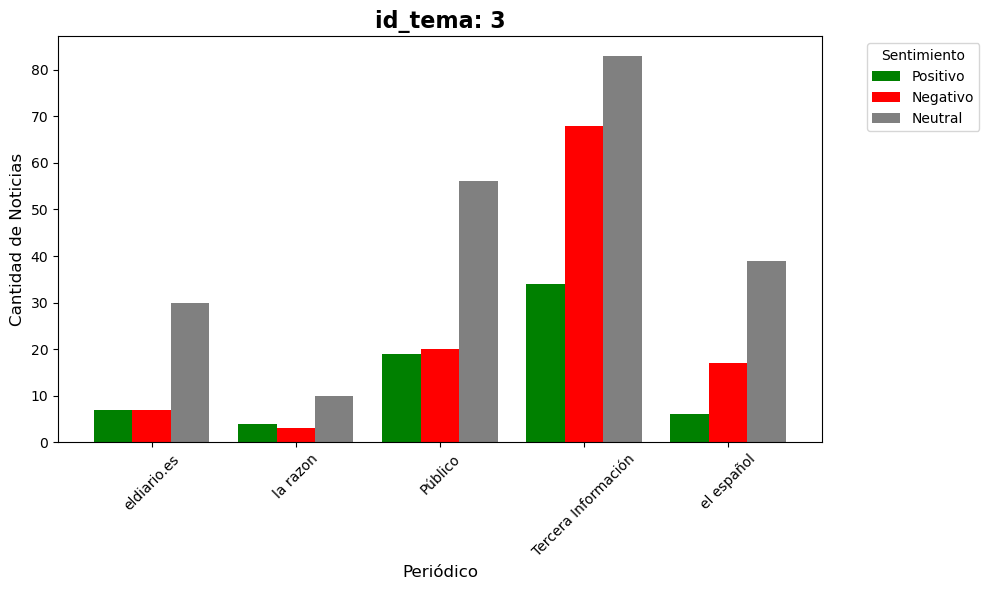

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es         0         5        5
1             la razon         8        19       28
2              Público        10        16       26
3  Tercera Información         8        39       45
4           el español         9        25       30


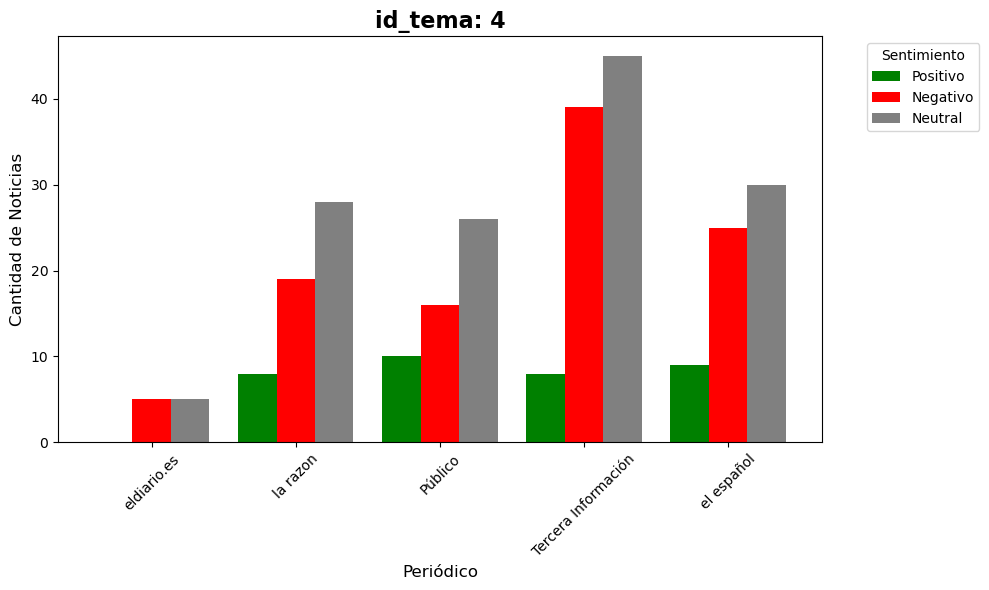

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es         4         4       21
1             la razon         9         4        8
2              Público        11         6       32
3  Tercera Información        16        16       59
4           el español         3         2       12


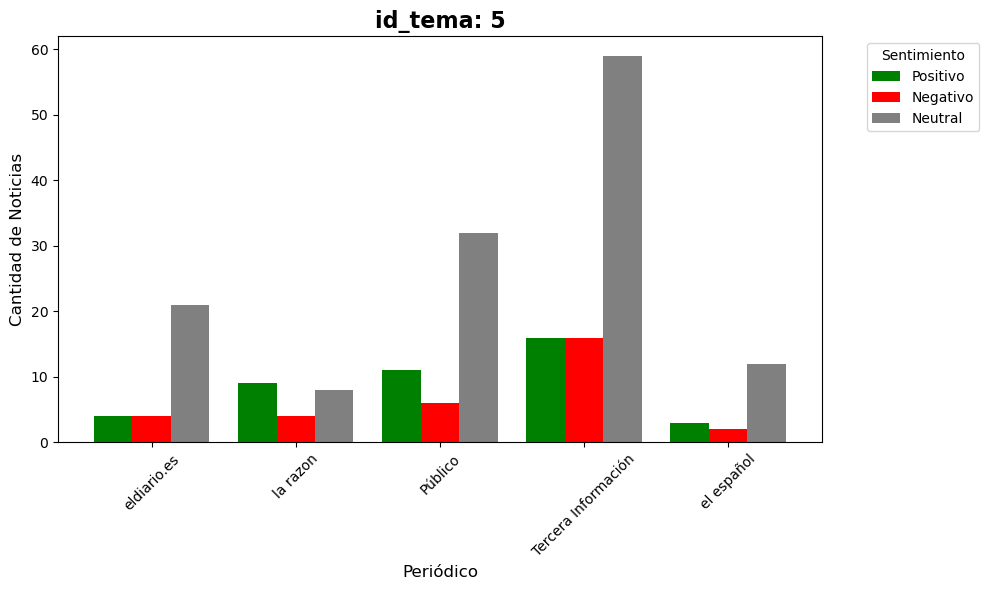

In [20]:
for tema in np.unique(df['id_tema']): 

    df_pol = pd.DataFrame()
    list_dic = []

    periodicos = df['periodico'].unique()

    for i in periodicos:
        
        df_sub = df[(df['periodico'] == i) & (df['id_tema'] == tema)]

        dic = {
            'Periodico': i,
            'Positivo': len(df_sub[df_sub['sentimiento'] == 'Positivo']),
            'Negativo': len(df_sub[df_sub['sentimiento'] == 'Negativo']),
            'Neutral': len(df_sub[df_sub['sentimiento'] == 'Neutral'])
        }
        list_dic.append(dic)

    df_pol = pd.DataFrame(list_dic)
    print(df_pol)

    datos_grafica = df_pol.set_index('Periodico')[['Positivo', 'Negativo', 'Neutral']]
    datos_grafica.plot(kind='bar', figsize=(10, 6), color=['green', 'red', 'gray'], width=0.8)
    plt.title(f'id_tema: {tema}', fontsize=16, fontweight='bold')
    plt.xlabel('Periódico', fontsize=12)
    plt.ylabel('Cantidad de Noticias', fontsize=12)
    plt.xticks(rotation=45) 
    plt.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Análisis de la palabra Pedro Sanchez

In [21]:
from pysentimiento import create_analyzer
import pandas as pd
import re

analyzer = create_analyzer(task="sentiment", lang="es")

# Filtrar noticias sobre Pedro Sánchez
patron = re.compile(
    r'\bpedro\s+s[áa]nchez\b'
    r'|\bel\s+presidente\s+del\s+gobierno\b'
    r'|\bel\s+presidente\s+s[áa]nchez\b'
    r'|\bel\s+l[íi]der\s+del\s+psoe\b',
    re.IGNORECASE
)
df_s = df[df["texto"].str.contains(patron) | df["titulo"].str.contains(patron)].copy()

# Extraer solo las frases que mencionan a Sánchez (contexto)
def contexto_sanchez(texto, ventana=5):
    frases = re.split(r"(?<=[\.\!\?])\s+", texto)
    idx = set()
    for i, f in enumerate(frases):
        if patron.search(f):
            idx.update(range(max(0, i-ventana), min(len(frases), i+ventana+1)))
    return " ".join(frases[i] for i in sorted(idx))[:1500]  # truncar para BERT

df_s["contexto"] = df_s["texto"].apply(contexto_sanchez)

# Predecir sentimiento (POS / NEG / NEU)
df_s["sentimiento"] = df_s["contexto"].apply(lambda t: analyzer.predict(t).output)

# Score numérico para promediar
mapa = {"POS": 1, "NEU": 0, "NEG": -1}
df_s["score"] = df_s["sentimiento"].map(mapa)

# Resumen por periódico
print(df_s.groupby("periodico")["score"].agg(["mean", "count"]))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                         mean  count
periodico                           
Público             -0.846473    241
Tercera Información -0.843750     64
el español          -0.852792    591
eldiario.es         -0.803681    163
la razon            -0.878981    471


sentimiento          POS  NEU  NEG
periodico                         
el español            16   55  520
la razon               8   41  422
Público                5   27  209
eldiario.es            3   26  134
Tercera Información    2    6   56


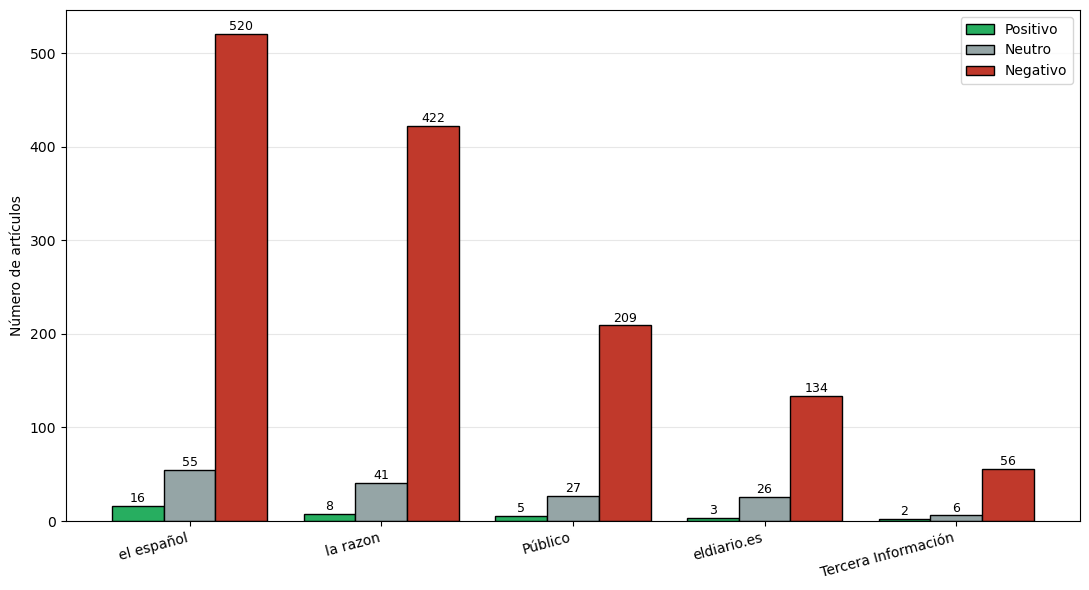

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Recuento absoluto por periódico y sentimiento
recuento = df_s.groupby(['periodico', 'sentimiento']).size().unstack(fill_value=0)

# Asegurar que están las tres columnas en orden
for col in ['POS', 'NEU', 'NEG']:
    if col not in recuento.columns:
        recuento[col] = 0
recuento = recuento[['POS', 'NEU', 'NEG']]
recuento = recuento.sort_values('POS', ascending=False)

print(recuento)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(recuento))
ancho = 0.27

b1 = ax.bar(x - ancho, recuento['POS'], ancho, label='Positivo', color='#27ae60', edgecolor='black')
b2 = ax.bar(x,         recuento['NEU'], ancho, label='Neutro',   color='#95a5a6', edgecolor='black')
b3 = ax.bar(x + ancho, recuento['NEG'], ancho, label='Negativo', color='#c0392b', edgecolor='black')

# Números encima de cada barra
for barras in (b1, b2, b3):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(recuento.index, rotation=15, ha='right')
ax.set_ylabel('Número de artículos')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Preparación de datos para entrenamiento de modelos

In [23]:
# Obtenemos el modelo de umap
umap_trained = topic_model.umap_model

# Calculamos las variables en el espacio reducido
X = umap_trained.transform(embeddings)
X

array([[-0.5810461 ,  3.325051  , -0.35794204,  0.48271278, 11.912491  ],
       [ 0.5588886 ,  2.4205933 ,  2.4651244 ,  2.4947915 , 11.649391  ],
       [-0.582914  ,  3.3259768 , -0.3535518 ,  0.4868358 , 11.908883  ],
       ...,
       [ 0.3095736 ,  2.816458  ,  0.10298507,  0.44744176, 11.781339  ],
       [-0.19528888,  4.0484014 ,  1.7615794 ,  1.4780254 , 12.358261  ],
       [ 0.23296234,  4.522556  ,  0.98648906,  1.8754942 , 12.456146  ]],
      shape=(10000, 5), dtype=float32)

In [24]:
y1 = df[['periodico']]
y1.head(5)

,periodico
0,eldiario.es
1,eldiario.es
2,eldiario.es
3,eldiario.es
4,eldiario.es


In [25]:
y2 = df[['id_tema']]
y2.head(5)

,id_tema
0,0
1,0
2,0
3,0
4,0


In [26]:
# Guardar las columnas de X dentro del dataframe
for i in range(X.shape[1]):
    df[f"x_{i}"] = X[:, i]

# Crear variable ideológica
mapa_ideologia = {
    "eldiario.es": "izquierda",
    "Público": "izquierda",
    "Tercera Información": "izquierda",
    "la razon": "derecha",
    "el español": "derecha"
}

df["ideologia"] = df["periodico"].map(mapa_ideologia)

## Entrenamiento de clasificadores

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

RANDOM_STATE = 42

Variables predictoras:

- `x_0`
- `x_1`
- `x_2`
- `x_3`
- `x_4`

Variables objetivo:

- `periodico`
- `ideologia`
- `id_tema`


In [28]:
feature_cols = ["x_0", "x_1", "x_2", "x_3", "x_4"]
target_cols = ["periodico", "ideologia", "id_tema"]

X = df[feature_cols].copy()

print("Variables predictoras:", feature_cols)
print("Objetivos:", target_cols)


Variables predictoras: ['x_0', 'x_1', 'x_2', 'x_3', 'x_4']
Objetivos: ['periodico', 'ideologia', 'id_tema']


Creamos una función que entrene y evalue un modelo dado.

In [29]:
def train_and_evaluate_objective(df, objective, feature_cols):
    X = df[feature_cols].copy()
    y_raw = df[objective].astype(str).copy()

    encoder = LabelEncoder()
    y = encoder.fit_transform(y_raw)
    class_names = [str(c) for c in encoder.classes_]

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X,
        y,
        df.index,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    models = {
        "Random_Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob" if len(class_names) > 2 else "binary:logistic",
            eval_metric="mlogloss" if len(class_names) > 2 else "logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    metrics_rows = []
    predictions = {}

    for model_name, model in models.items():

        print("="*70)
        print(f"Objetivo: {objective} | Modelo: {model_name}")
        print("="*70)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")

        metrics_rows.append({
            "objetivo": objective,
            "modelo": model_name,
            "accuracy": acc,
            "f1_macro": f1_macro
        })

        cols_base = ["periodico", "titulo", "texto", "url", "ideologia", "id_tema"]
        cols_base = [c for c in cols_base if c in df.columns]

        pred_df = df.loc[idx_test, cols_base].copy()
        pred_df["objetivo"] = objective
        pred_df["modelo"] = model_name
        pred_df["real"] = encoder.inverse_transform(y_test)
        pred_df["predicho"] = encoder.inverse_transform(y_pred)
        pred_df["correcto"] = pred_df["real"] == pred_df["predicho"]
        pred_df["confianza"] = y_proba.max(axis=1)

        predictions[model_name] = pred_df

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(ax=ax, xticks_rotation=45, values_format="d")
        #ax.set_title(f"Matriz de confusión - {objective} - {model_name}")
        ax.set_title(f"{model_name}")
        plt.tight_layout()
        plt.show()

        print(classification_report(y_test, y_pred, target_names=class_names))

    metrics_df = pd.DataFrame(metrics_rows)

    return {
        "metrics": metrics_df,
        "predictions": predictions,
        "classes": class_names
    }


Entrenamos diferentes modelos.

Objetivo: periodico | Modelo: Random_Forest


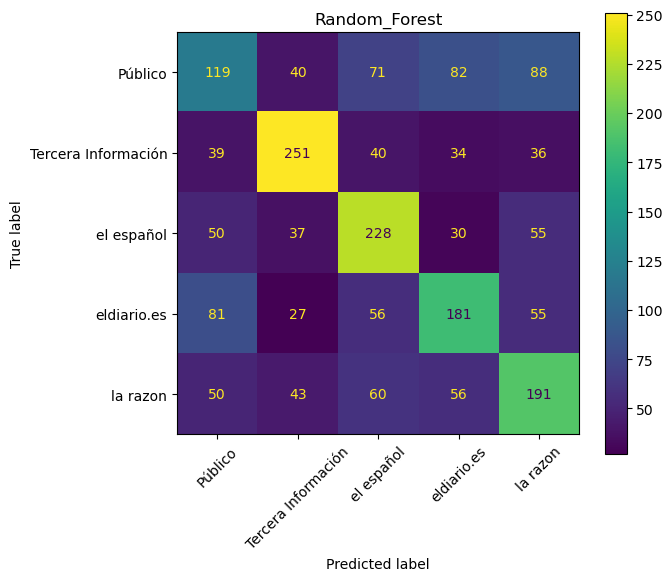

                     precision    recall  f1-score   support

            Público       0.35      0.30      0.32       400
Tercera Información       0.63      0.63      0.63       400
         el español       0.50      0.57      0.53       400
        eldiario.es       0.47      0.45      0.46       400
           la razon       0.45      0.48      0.46       400

           accuracy                           0.48      2000
          macro avg       0.48      0.48      0.48      2000
       weighted avg       0.48      0.48      0.48      2000

Objetivo: periodico | Modelo: XGBoost


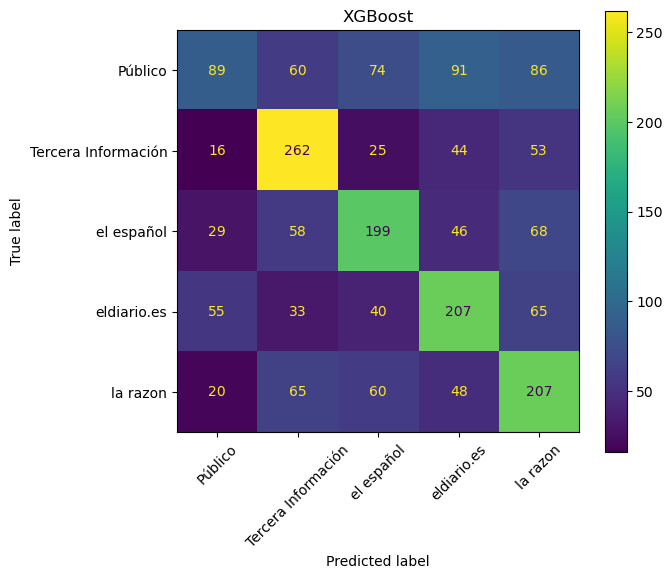

                     precision    recall  f1-score   support

            Público       0.43      0.22      0.29       400
Tercera Información       0.55      0.66      0.60       400
         el español       0.50      0.50      0.50       400
        eldiario.es       0.47      0.52      0.50       400
           la razon       0.43      0.52      0.47       400

           accuracy                           0.48      2000
          macro avg       0.48      0.48      0.47      2000
       weighted avg       0.48      0.48      0.47      2000

Objetivo: ideologia | Modelo: Random_Forest


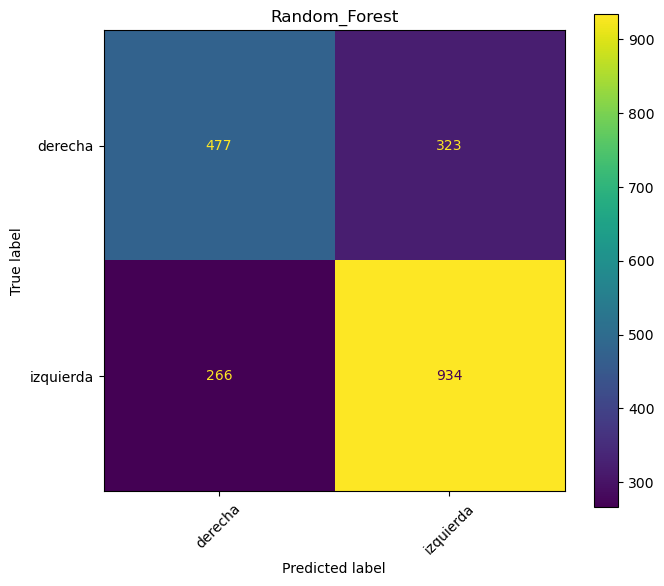

              precision    recall  f1-score   support

     derecha       0.64      0.60      0.62       800
   izquierda       0.74      0.78      0.76      1200

    accuracy                           0.71      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.70      0.71      0.70      2000

Objetivo: ideologia | Modelo: XGBoost


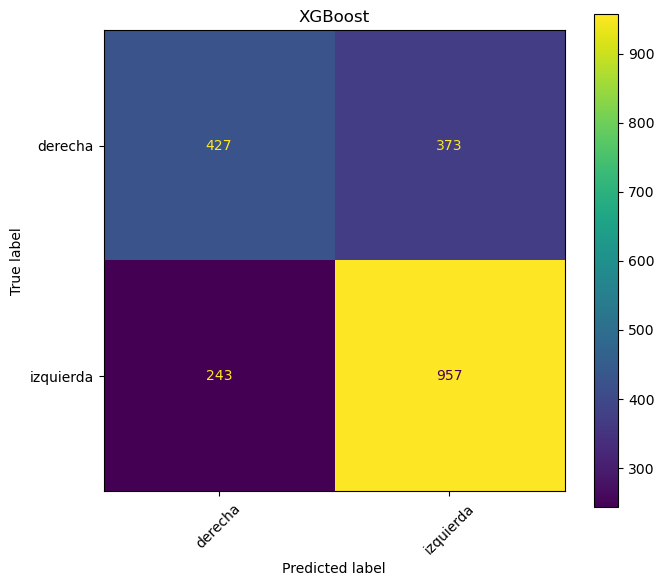

              precision    recall  f1-score   support

     derecha       0.64      0.53      0.58       800
   izquierda       0.72      0.80      0.76      1200

    accuracy                           0.69      2000
   macro avg       0.68      0.67      0.67      2000
weighted avg       0.69      0.69      0.69      2000

Objetivo: id_tema | Modelo: Random_Forest


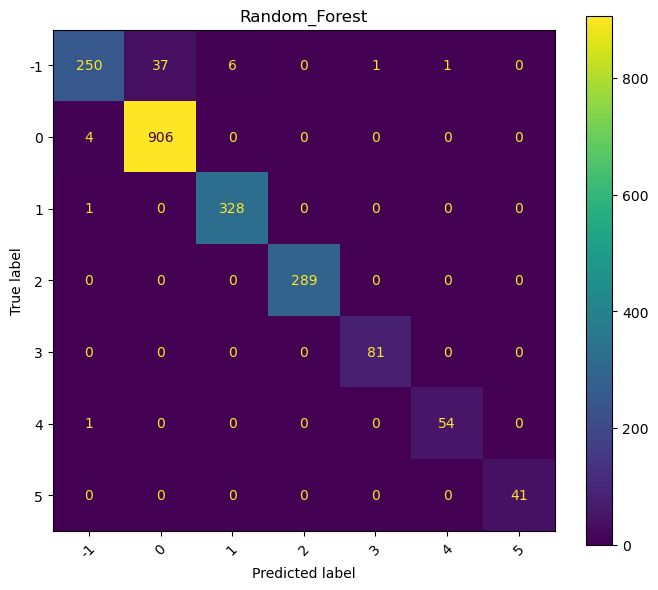

              precision    recall  f1-score   support

          -1       0.98      0.85      0.91       295
           0       0.96      1.00      0.98       910
           1       0.98      1.00      0.99       329
           2       1.00      1.00      1.00       289
           3       0.99      1.00      0.99        81
           4       0.98      0.98      0.98        55
           5       1.00      1.00      1.00        41

    accuracy                           0.97      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.97      0.97      0.97      2000

Objetivo: id_tema | Modelo: XGBoost


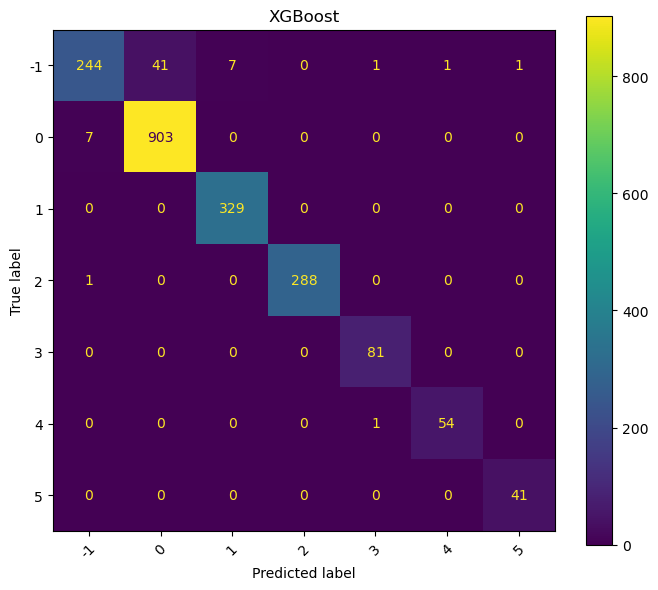

              precision    recall  f1-score   support

          -1       0.97      0.83      0.89       295
           0       0.96      0.99      0.97       910
           1       0.98      1.00      0.99       329
           2       1.00      1.00      1.00       289
           3       0.98      1.00      0.99        81
           4       0.98      0.98      0.98        55
           5       0.98      1.00      0.99        41

    accuracy                           0.97      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [30]:
results = {}

for objective in target_cols:
    results[objective] = train_and_evaluate_objective(
        df=df,
        objective=objective,
        feature_cols=feature_cols
    )

Creamos una tabla con las métricas de los modelos desarrollados.

In [31]:
tabla_metricas = pd.concat(
    [results[obj]["metrics"] for obj in target_cols],
    ignore_index=True
)

tabla_metricas = tabla_metricas.sort_values(["objetivo", "f1_macro"], ascending=[True, False])

tabla_metricas

,objetivo,modelo,accuracy,f1_macro
4,id_tema,Random_Forest,0.9745,0.978634
5,id_tema,XGBoost,0.9700,0.973081
2,ideologia,Random_Forest,0.7055,0.689276
3,ideologia,XGBoost,0.6920,0.668737
0,periodico,Random_Forest,0.4850,0.481964
1,periodico,XGBoost,0.4820,0.470809
